# Data Acquisition, Cleaning, and Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd

In [2]:
# PROVIDE CITATION FOR THIS CODEBLOCK

# Test nba_api connection

from nba_api.stats.static import teams

nba_teams = teams.get_teams()
print(f"Successfully connected! Found {len(nba_teams)} teams.")

Successfully connected! Found 30 teams.


This next code block uses LeagueGameFinder to retrieve game IDs for the 2024-2025 Portland Trail Blazers season.

One of the resulting game IDs will be used for exploration.

In [3]:
# PROVIDE CITATION FOR THIS CODEBLOCK

from nba_api.stats.endpoints import leaguegamefinder

# Get a list of all NBA teams and find the ID for a specific team
nba_teams = teams.get_teams()
blazers = [team for team in nba_teams if team['abbreviation'] == 'POR'][0]
blazers_id = blazers['id']

# Query for games where the Blazers played during a specific season
gamefinder = leaguegamefinder.LeagueGameFinder(
    team_id_nullable=blazers_id,
    season_nullable='2024-25' # Specify the season
)

# Get the data frame and extract unique game IDs
games_df = gamefinder.get_data_frames()[0]
game_ids = games_df['GAME_ID'].unique().tolist()

print(f"Found {len(game_ids)} game IDs for the 2024-25 Trail Blazers season.")
print(game_ids[-1]) # Print the last game ID

Found 86 game IDs for the 2024-25 Trail Blazers season.
0012400035


<span style="color: red">We attempted to fetch game data through the API's playbyplay endpoint, but encountered persistent ReadTimeoutErrors, despite trying multiple methods including specifying User-Agent headers, randomizing browser strings through fake_useragent, manually configuring the underlying library's session through requests.Session(), setting up retries, etc. If more casual language is to be allowed, this was one big data engineering headache for a novice data scientist. We have left one such instance of a failure below.</span> 

<span style="color: red">Unable to traverse this technical hurdle, we concluded that our IP address had been flagged (though there has been speculation that the league is throttling access to api endpoints due to the advent of sports betting). With limited time for the project, this forced a pivot to using a local data source during the modeling phase.</span> 

<b><span style="color: red">The API issue will be addressed and ideally resolved during the "Integration" phase where we move from a static model to a functional tool.</span></b>

In [4]:
# PROVIDE CITATION FOR THIS CODEBLOCK

import time
from nba_api.stats.endpoints import playbyplay

headers = {
    'Host': 'stats.nba.com',
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:61.0) Gecko/20100101 Firefox/61.0',
    'Accept': 'application/json, text/plain, */*',
    'Accept-Language': 'en-US,en;q=0.5',
    'Referer': 'https://stats.nba.com/',
    'Accept-Encoding': 'gzip, deflate, br',
    'Connection': 'keep-alive',
    'x-nba-stats-origin': 'stats',
    'x-nba-stats-token': 'true'
}

def get_pbp_with_retry(game_id, retries=3):
    for i in range(retries):
        try:
            pbp = playbyplay.PlayByPlay(game_id, headers=headers)
            return pbp.get_data_frames()[0]
        except Exception as e:
            print(f"Error: {e}, retrying {i+1}/{retries}...")
            time.sleep(2 ** i) # Exponential backoff
    return None

df = get_pbp_with_retry('0012400035')
df.head()

Error: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=30), retrying 1/3...
Error: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=30), retrying 2/3...
Error: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=30), retrying 3/3...


AttributeError: 'NoneType' object has no attribute 'head'

BIG NOTE about pivot to new app idea that doesn't rely on live data. Talk about local data source on GitHub. Fortunately somebody has been actively uploading play by play data for recent seasons, even including some games from this most current season.

Load random set of games from season. More notes - start and edit from below:

This sample size represents roughly 20% of the total data. In sports analytics research, 500 games (approximately 250,000 individual play-by-play rows) provide enough "comeback" events and "clutch" scenarios to make visualizations significant.

With 500 games, the home-win percentage will reliably hover around the 58–60% mark, allowing us to establish a credible baseline without the usual "noise" that results from smaller samples.

Also, 500 games of play-by-play data typically take up ~80-100 MB in a DataFrame. This fits easily in memory.

In [5]:
def get_data_sample(file_path, num_games=500):
    # Only read the gameId column first to identify unique games
    unique_ids = pd.read_csv(file_path, usecols=['gameId'])['gameId'].unique()
    sampled_ids = unique_ids[:num_games] # Take the first 500
    
    # Load rows only for those games
    full_df = pd.read_csv(file_path)
    return full_df[full_df['gameId'].isin(sampled_ids)]

df = get_data_sample('/Users/thomaslee/Desktop/MS_in_DS/DTSC_691_PROJECT/data/nbastatsv3_2024.csv')

# Count unique values in 'gameId' column of resulting dataframe to ensure we have 500 games
n = len(pd.unique(df['gameId']))

print("Number of games captured:", n)

Number of games captured: 500


In [6]:
# Want to convert gameId and teamId immediately to preserve leading zeros
# Also want to sort dataframe immediately after loading by gameId then actionId

In [7]:
# Get slice of resulting dataframe

df.head()

,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,...,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,shotValue,actionId,gameId
0,2,PT12M00.00S,1,0,NaN,0,NaN,NaN,0,0,...,0.0,0,NaN,Start of 1st Period (7:11 PM EST),period,start,0,0,1,22400001
1,4,PT12M00.00S,1,1610612738,BOS,201143,Horford,A. Horford,0,0,...,NaN,0,h,Jump Ball Horford vs. Capela: Tip to Wallace,Jump Ball,NaN,1,0,2,22400001
2,7,PT11M43.00S,1,1610612737,ATL,1642258,Risacher,Z. Risacher,-168,205,...,NaN,0,v,MISS Risacher 27' 3PT Jump Shot,Missed Shot,Jump Shot,1,3,3,22400001
3,7,PT11M43.00S,1,1610612738,BOS,1628369,Tatum,J. Tatum,0,0,...,NaN,0,h,Tatum BLOCK (1 BLK),NaN,NaN,1,3,4,22400001
4,9,PT11M42.00S,1,1610612737,ATL,1642258,Risacher,Z. Risacher,0,0,...,NaN,0,v,Risacher REBOUND (Off:1 Def:0),Rebound,Unknown,1,0,5,22400001


Let's look at the columns one-by-one. Also assess whether any can be dropped since they won't serve as valuable features for our model.

| Column Name | Description | Status | Reasoning / Utility |
| --- | --- | --- | --- |
| **actionNumber** | Bundled actions in order of play | **Drop** | Redundant due to actionId |
| **clock** | ISO 8601 string of time left | **Keep** | Will become primary feature once parsed into seconds |
| **period** | Current quarter (including OT) | **Keep** | Vital context for the weight of the score margin |
| **teamId** | Unique numerical ID for the team | **Keep** | Used to determine possession and team ratings |
| **teamTricode** | 3-letter team abbr | **Drop** | Redundant due to teamId |
| **personId** | Unique player ID | **Drop** | Too granular |
| **playerName** | Full name of the player | **Drop** | Too granular |
| **playerNameI** | Initial + Last name | **Drop** | Redundant due to playerName |
| **xLegacy / yLegacy** | Coordinate data for shots | **Drop** | Too granular |
| **shotDistance** | Distance in feet from the hoop | **Drop** | Too granular |
| **shotResult** | 'Made' vs 'Missed' | **Keep** | Critical for tracking scoring runs |
| **isFieldGoal** | 1 for shot, 0 for otherwise | **Drop** | Redundant due to actionType |
| **scoreHome** | Current points for home team | **Keep** | Core feature for score margin |
| **scoreAway** | Current points for away team | **Keep** | Core feature for score margin |
| **pointsTotal** | Total game points at that time | **Drop** | Not useful; score margin will be primary feature related to scoring |
| **location** | Home vs Visitor indicator | **Keep** | Essential for Home Court Advantage baseline |
| **description** | Text description of the play | **Keep** | Will help with possession indicator feature later |
| **actionType** | Categorizes type of basketball play | **Keep** | Essential for determining timeouts and fouls |
| **subType** | Gets into specifics | **Drop** | Too granular |
| **videoAvailable** | Binary for availability of video highlights | **Drop** | Metadata; no predictive value |
| **shotValue** | Points worth (2, 3, or 1 for FT) | **Drop** | Dropped in favor of cumulative score margin |
| **actionId** | Unique ID for specific row | **Keep** | Can set this as chronological sorting anchor |
| **gameId** | Unique ID for the game | **Keep** | Vital for grouping rows by game |

Drop unnecessary columns. This will help reduce memory footprint by a significant amount.

In [8]:
dropped_columns = ['teamTricode', 'personId', 'playerName', 'playerNameI', 
                'xLegacy', 'yLegacy', 'shotDistance', 'isFieldGoal', 
                'pointsTotal', 'subType', 'videoAvailable', 'shotValue', 
                'actionNumber']

df_clean = df.drop(columns=dropped_columns)
df_clean.head()

,clock,period,teamId,shotResult,scoreHome,scoreAway,location,description,actionType,actionId,gameId
0,PT12M00.00S,1,0,NaN,0.0,0.0,NaN,Start of 1st Period (7:11 PM EST),period,1,22400001
1,PT12M00.00S,1,1610612738,NaN,NaN,NaN,h,Jump Ball Horford vs. Capela: Tip to Wallace,Jump Ball,2,22400001
2,PT11M43.00S,1,1610612737,Missed,NaN,NaN,v,MISS Risacher 27' 3PT Jump Shot,Missed Shot,3,22400001
3,PT11M43.00S,1,1610612738,NaN,NaN,NaN,h,Tatum BLOCK (1 BLK),NaN,4,22400001
4,PT11M42.00S,1,1610612737,NaN,NaN,NaN,v,Risacher REBOUND (Off:1 Def:0),Rebound,5,22400001


## Temporary Header: Cleaning the Data

scoreHome and scoreAway are NaN for all rows except rows where there is a Made Shot under actionType.

Last known scores for both teams need to be propagated forward until a new one occurs.

(pulled from Gemini)
Why this is critical for your Project
Model Features: Your model needs to know the score_margin at every moment, not just when someone scores. If a team is holding a lead for 3 minutes without anyone scoring, that "stagnant" lead is a vital piece of information for the Win Probability.

App Experience: In your "Historical Replay" slider, as the user scrubs through actionId 5, 6, 7, and 8 (which are blocks and rebounds in your image), the score gauge needs to stay at 0-0 or whatever the current score is, rather than showing "N/A."

Data Integrity: By using .groupby('gameId'), you ensure that the score resets to 0-0 at the start of every new gameId in your 500-game sample.

In [9]:
# Replace empty cells with NaN for using ffill
df_clean[['scoreHome', 'scoreAway']] = df_clean[['scoreHome', 'scoreAway']].replace('', np.nan)

# Sort by game and actionId to ensure perfect chronological order
df_clean = df_clean.sort_values(['gameId', 'actionId'])

# Fill the NaNs forward within each game group
# This prevents the final score of one game from leaking into the next
df_clean['scoreHome'] = df_clean.groupby('gameId')['scoreHome'].ffill()
df_clean['scoreAway'] = df_clean.groupby('gameId')['scoreAway'].ffill()

# Check larger head of dataframe to confirm implementation
df_clean.head(50)

,clock,period,teamId,shotResult,scoreHome,scoreAway,location,description,actionType,actionId,gameId
0,PT12M00.00S,1,0,NaN,0.0,0.0,NaN,Start of 1st Period (7:11 PM EST),period,1,22400001
1,PT12M00.00S,1,1610612738,NaN,0.0,0.0,h,Jump Ball Horford vs. Capela: Tip to Wallace,Jump Ball,2,22400001
2,PT11M43.00S,1,1610612737,Missed,0.0,0.0,v,MISS Risacher 27' 3PT Jump Shot,Missed Shot,3,22400001
3,PT11M43.00S,1,1610612738,NaN,0.0,0.0,h,Tatum BLOCK (1 BLK),NaN,4,22400001
4,PT11M42.00S,1,1610612737,NaN,0.0,0.0,v,Risacher REBOUND (Off:1 Def:0),Rebound,5,22400001
5,PT11M38.00S,1,1610612737,Missed,0.0,0.0,v,MISS Johnson 14' Driving Floating Bank Jump Shot,Missed Shot,6,22400001
6,PT11M37.00S,1,1610612738,NaN,0.0,0.0,h,Horford REBOUND (Off:0 Def:1),Rebound,7,22400001
7,PT11M24.00S,1,1610612738,Missed,0.0,0.0,h,MISS White 28' 3PT Jump Shot,Missed Shot,8,22400001
8,PT11M22.00S,1,1610612737,NaN,0.0,0.0,v,Johnson REBOUND (Off:0 Def:1),Rebound,9,22400001
9,PT11M17.00S,1,1610612737,NaN,0.0,0.0,v,Johnson Traveling Turnover (P1.T1),Turnover,10,22400001


shotResults NaNs: Leave as they are for now since the model will handle them natively as a "not applicable" category. Replacing with a string like "None" will only increase memory usage.

teamId: In play-by-play data, the "0"s typically occur on neutral events, such as the start of a game or a jump ball before possession is established. Can keep the 0s for now since they'll be handled later in feature engineering.

location: Leave NaNs for neutral game events.

actionType: NaNs are for events like Steals and Blocks that aren't categorized into primary actionTypes since they are covered by actions that immediately precede or succeed them like Turnovers and Rebounds. Can leave alone.

Check column datatypes for opportunities to convert and clean up.

In [10]:
df_clean.dtypes

clock           object
period           int64
teamId           int64
shotResult      object
scoreHome      float64
scoreAway      float64
location        object
description     object
actionType      object
actionId         int64
gameId           int64
dtype: object

ADD NOTES ABOUT DATA TYPES AND WHATNOT.

Especially downcasting to int16 or whatever to satisfy memory optimization requirements

| Column | Recommended Type | Why? |
| --- | --- | --- |
| **`gameId`** | `object` (string) | Preserves leading zeros and prevents math errors. |
| **`teamId`** | `object` (string) | Preserves leading zeros for ID matching. |
| **`actionId`** | `int16` | Can handle up to 32,767 (NBA games usually have ~500 actions). |
| **`period`** | `int8` | Only needs to hold values 1-10 (Quarters + Overtimes). |
| **`scoreHome`** | `int16` | Can handle up to 32,767 (Way more than any NBA score). |
| **`scoreAway`** | `int16` | Same as home score. |
| **`location`** | `category` | High memory savings for 'h'/'v'. |
| **`description`** | `object` (string) | Text description stored as string. |
| **`actionType`** | `category` | High memory savings for repetitive play types. |
| **`shotResult`** | `category` | High memory savings for 'Made'/'Missed'. |
| **`clock`** | `object` (string) | Kept as string for now but will be parsed into seconds later. |

Map and apply datatype changes.

In [11]:
# Define the data type mapping
dtype_mapping = {
    'gameId': object,
    'teamId': object,
    'actionId': 'int16',
    'period': 'int8',
    'scoreHome': 'int16',
    'scoreAway': 'int16',
    'location': 'category',
    'description': object,
    'actionType': 'category',
    'shotResult': 'category',
    'clock': object # will be parsed into total seconds afterwards
}

# Apply the mapping
df_clean = df_clean.astype(dtype_mapping)
df_clean.dtypes

clock            object
period             int8
teamId           object
shotResult     category
scoreHome         int16
scoreAway         int16
location       category
description      object
actionType     category
actionId          int16
gameId           object
dtype: object

Show memory footprint reduction from downcasting datatypes.

In [12]:
# CITE CODE HERE

def get_memory_usage(df):
    # Returns memory usage in Megabytes
    return df.memory_usage(deep=True).sum() / (1024**2)

# Calculate savings
mem_before = get_memory_usage(df) # Assuming you kept a copy
mem_after = get_memory_usage(df_clean)
saving_pct = 100 * (1 - (mem_after / mem_before))

print(f"Original Memory: {mem_before:.2f} MB")
print(f"Optimized Memory: {mem_after:.2f} MB")
print(f"Total Savings: {saving_pct:.2f}%")

Original Memory: 150.61 MB
Optimized Memory: 56.04 MB
Total Savings: 62.79%


Downcasting converts data into the smallest possible "containers," which drastically reduces the memory footprint of the dataset. This will allow our model to train much faster, enable more thorough hyperparameter tuning on a standard computer, and ensure our final app responds instantly to user inputs.

The data in the 'clock' column uses ISO 8601 strings (e.g., PT10M30.00S). The model needs a numerical input, so conversion to total seconds is needed. Code below.

In [13]:
# CITE CODE HERE

import re

def parse_nba_clock(clock_str):
    if not isinstance(clock_str, str):
        return 0
    # Extract minutes and seconds using regex
    match = re.search(r'PT(\d+)M(\d+)', clock_str)
    if match:
        minutes = int(match.group(1))
        seconds = int(match.group(2))
        return (minutes * 60) + seconds
    return 0

# Test it
print(parse_nba_clock("PT11M04.00S")) # Should output 664

664


In [14]:
# Apply the function to the 'clock' column
df_clean['seconds_remaining'] = df_clean['clock'].apply(parse_nba_clock)

# Since we want to optimize for memory, convert to int16 (Max 720 seconds in a quarter)
df_clean['seconds_remaining'] = df_clean['seconds_remaining'].astype('int16')

# Verify the first few rows
df_clean.head()

,clock,period,teamId,shotResult,scoreHome,scoreAway,location,description,actionType,actionId,gameId,seconds_remaining
0,PT12M00.00S,1,0,NaN,0,0,NaN,Start of 1st Period (7:11 PM EST),period,1,22400001,720
1,PT12M00.00S,1,1610612738,NaN,0,0,h,Jump Ball Horford vs. Capela: Tip to Wallace,Jump Ball,2,22400001,720
2,PT11M43.00S,1,1610612737,Missed,0,0,v,MISS Risacher 27' 3PT Jump Shot,Missed Shot,3,22400001,703
3,PT11M43.00S,1,1610612738,NaN,0,0,h,Tatum BLOCK (1 BLK),NaN,4,22400001,703
4,PT11M42.00S,1,1610612737,NaN,0,0,v,Risacher REBOUND (Off:1 Def:0),Rebound,5,22400001,702


Why add seconds remaining instead of converting everything under the 'clock' column?

The 'clock' will add as a human-readable anchor so when the app is built, the time can be displayed on the screen.

Also, it's important to maintain data lineage so if there is an unexpected result or error down the line, the original 'clock' string can be checked for quick verification.

The 'seconds_remaining' is a quarter-level feature. A global feature, e.g. 'total_game_seconds_remaining', is needed to track time decay throughout the entirety of a game, which will be explored further in an ensuring feature engineering notebook.

## The "Ground Truth" AKA Target Variable: HOME_WINS

Ultimately, the model needs to know who won each game in order to function at its most basic level. However, none of the current columns present a binary win or lose state so it needs to be created.

In [15]:
# Create a mapping of Game ID to the final result
final_scores = df_clean.groupby('gameId').tail(1).copy()
final_scores['HOME_WINS'] = (final_scores['scoreHome'] > final_scores['scoreAway']).astype(int)

# Create a dictionary for easy mapping
win_map = final_scores.set_index('gameId')['HOME_WINS'].to_dict()

# Map the final result back to every row in the dataset
df_clean['HOME_WINS'] = df_clean['gameId'].map(win_map)

df_clean.head() # Including this here, but it's not an effective way of confirming the implementation

,clock,period,teamId,shotResult,scoreHome,scoreAway,location,description,actionType,actionId,gameId,seconds_remaining,HOME_WINS
0,PT12M00.00S,1,0,NaN,0,0,NaN,Start of 1st Period (7:11 PM EST),period,1,22400001,720,0
1,PT12M00.00S,1,1610612738,NaN,0,0,h,Jump Ball Horford vs. Capela: Tip to Wallace,Jump Ball,2,22400001,720,0
2,PT11M43.00S,1,1610612737,Missed,0,0,v,MISS Risacher 27' 3PT Jump Shot,Missed Shot,3,22400001,703,0
3,PT11M43.00S,1,1610612738,NaN,0,0,h,Tatum BLOCK (1 BLK),NaN,4,22400001,703,0
4,PT11M42.00S,1,1610612737,NaN,0,0,v,Risacher REBOUND (Off:1 Def:0),Rebound,5,22400001,702,0


In [16]:
# Check value counts for home wins vs away wins
print(f"Total Rows: {len(df_clean)}")
print(df_clean['HOME_WINS'].value_counts())

# Check home win %
home_win_pct = df_clean.groupby('gameId')['HOME_WINS'].first().mean() * 100
print("\n")
print(f"\033[1mHome Win % = {home_win_pct:.2f}%\033[0m")

Total Rows: 247822
HOME_WINS
1    136532
0    111290
Name: count, dtype: int64


Home Win % = 55.20%


In the NBA, the home team typically wins between 55% and 60% of the time. This sample reflects a realistic "Home Court Advantage," which means the model will have a solid, non-biased foundation to learn from.

## Exploratory Data Analysis & Visualizations

Distribution check of scoreHome and scoreAway. Any negative scores? Or any huge outliers like 300 points that could be errors?

In [17]:
print(f"Minimum for scoreHome is {min(df_clean['scoreHome'])}")
print(f"Maximum for scoreHome is {max(df_clean['scoreHome'])}")

Minimum for scoreHome is 0
Maximum for scoreHome is 155


Minimum of 0 is logical since all games start at 0 for both teams.

A score of 155 seems really high and warrants further investigation.

In [18]:
# Locate rows where scoreHome is 155

df_clean.loc[df_clean['scoreHome'] == 155]

,clock,period,teamId,shotResult,scoreHome,scoreAway,location,description,actionType,actionId,gameId,seconds_remaining,HOME_WINS
205789,PT00M50.90S,4,1610612763,NaN,155,123,h,Edey Free Throw 1 of 2 (21 PTS),Free Throw,553,22400414,50,1
205790,PT00M50.90S,4,1610612763,NaN,155,123,h,MISS Edey Free Throw 2 of 2,Free Throw,554,22400414,50,1
205791,PT00M48.90S,4,1610612761,NaN,155,123,v,Lawson REBOUND (Off:0 Def:2),Rebound,555,22400414,48,1
205792,PT00M40.10S,4,1610612761,Missed,155,123,v,MISS Temple 14' Driving Floating Jump Shot,Missed Shot,556,22400414,40,1
205793,PT00M38.20S,4,1610612761,NaN,155,123,v,Chomche REBOUND (Off:2 Def:0),Rebound,557,22400414,38,1
205794,PT00M31.70S,4,1610612761,Made,155,126,v,Lawson 26' 3PT Jump Shot (6 PTS) (Chomche 1 AST),Made Shot,558,22400414,31,1
205795,PT00M07.00S,4,0,NaN,155,126,h,GRIZZLIES Turnover: Shot Clock (T#18),Turnover,559,22400414,7,1
205796,PT00M00.00S,4,1610612761,Missed,155,126,v,MISS Temple 28' 3PT Step Back Jump Shot,Missed Shot,560,22400414,0,1
205797,PT00M00.00S,4,0,NaN,155,126,v,Raptors Rebound,Rebound,561,22400414,0,1
205798,PT00M00.00S,4,0,NaN,155,126,NaN,End of 4th Period (10:24 PM EST),period,562,22400414,0,1


While a score of 155 seems exceptionally high, there WAS a game in December 26, 2024 where the Memphis Grizzlies defeated the Toronto Raptors with a final score of 155-126. This was confirmed further through checking the teamIds as well as the gameId.

Now let's look at scoreAway.

In [19]:
print(f"Minimum for scoreAway is {min(df_clean['scoreAway'])}")
print(f"Maximum for scoreAway is {max(df_clean['scoreAway'])}")

Minimum for scoreAway is 0
Maximum for scoreAway is 149


In [20]:
# Locate rows where scoreAway is 149

df_clean.loc[df_clean['scoreAway'] == 149]

,clock,period,teamId,shotResult,scoreHome,scoreAway,location,description,actionType,actionId,gameId,seconds_remaining,HOME_WINS
210725,PT01M00.00S,4,1610612739,Made,132,149,v,Niang 25' 3PT Running Jump Shot (3 PTS) (Tyson...,Made Shot,482,22400424,60,0
210726,PT00M44.80S,4,1610612743,Made,135,149,h,Tyson 25' 3PT Jump Shot (3 PTS) (Pickett 1 AST),Made Shot,483,22400424,44,0
210727,PT00M33.60S,4,1610612739,Missed,135,149,v,MISS Jerome 26' 3PT Pullup Jump Shot,Missed Shot,484,22400424,33,0
210728,PT00M26.40S,4,1610612743,NaN,135,149,h,Strawther REBOUND (Off:0 Def:2),Rebound,485,22400424,26,0
210729,PT00M17.90S,4,1610612743,Missed,135,149,h,MISS Tyson 17' Fadeaway Jumper,Missed Shot,486,22400424,17,0
210730,PT00M14.70S,4,1610612739,NaN,135,149,v,Tyson REBOUND (Off:0 Def:1),Rebound,487,22400424,14,0
210731,PT00M00.00S,4,0,NaN,135,149,NaN,End of 4th Period (11:25 PM EST),period,488,22400424,0,0


While a score of 149 seems exceptionally high, there WAS a game in December 27, 2024 where the Cleveland Cavaliers defeated the Denver Nuggets with a final score of 155-126. This was confirmed further through checking the teamIds as well as the gameId.

### 3.2 Time Distribution Check
To verify the integrity of the `seconds_remaining` parser, we visualize the distribution of all events across the 720 seconds of a standard NBA quarter. 

**Expectation:** We expect a relatively "flat" or uniform distribution. While some spikes are normal (e.g., more fouls/timeouts at the very end of a quarter), massive spikes at `0` or `720` could indicate a parsing error where the function defaulted to a specific value for unreadable strings.

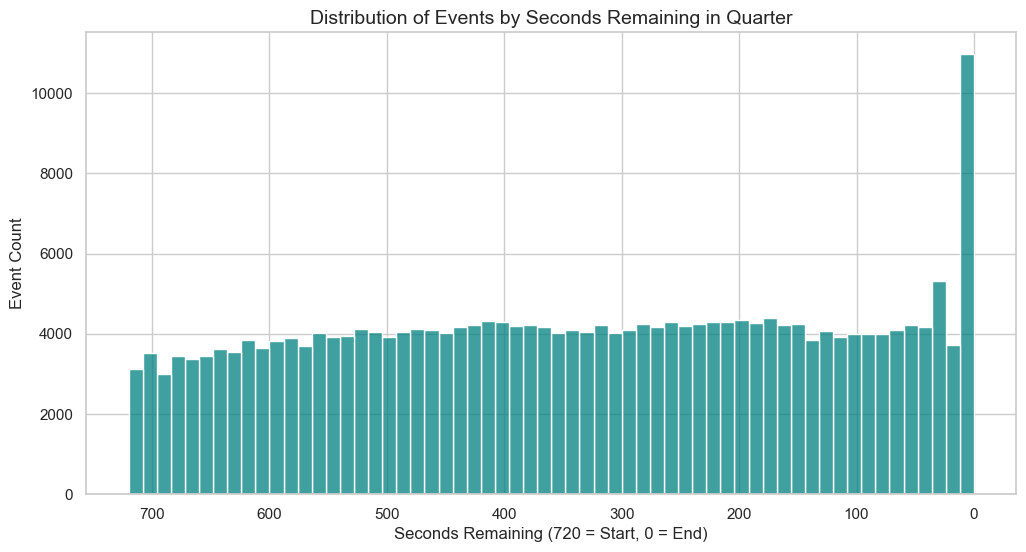

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for a professional look
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

# Plotting the histogram of seconds_remaining
sns.histplot(df_clean['seconds_remaining'], bins=60, kde=False, color='teal')

# Adding labels and titles
plt.title('Distribution of Events by Seconds Remaining in Quarter', fontsize=14)
plt.xlabel('Seconds Remaining (720 = Start, 0 = End)', fontsize=12)
plt.ylabel('Event Count', fontsize=12)

# Invert x-axis so 720 is on the left (start) and 0 is on the right (end)
plt.gca().invert_xaxis()

plt.show()

While the distribution between 720 and 30 seconds is clean and "flat", there's a massive spike (over 10,000 events) at the 0-second mark.

This is to be somewhat expected in NBA data since there is natural clustering around the end of a quarter due to buzzer-beaters, intentional fouls, substitutions, and period-end markers.

Run a quick check to ensure that the spike is "natural" (real end-of-period events) and not a "bug" (failed parsing).

In [22]:
# Look at a sample of the rows hitting the 0-second mark
check_zero = df_clean[df_clean['seconds_remaining'] == 0].head(10)
print(check_zero[['clock', 'actionType']])

           clock      actionType
133  PT00M00.40S     Missed Shot
134  PT00M00.40S         Rebound
135  PT00M00.00S          period
250  PT00M00.40S            Foul
251  PT00M00.40S  Instant Replay
252  PT00M00.40S      Free Throw
253  PT00M00.40S      Free Throw
254  PT00M00.00S          period
358  PT00M00.40S     Missed Shot
359  PT00M00.40S         Rebound


As expected and is exhibited in most NBA play-by-play datasets, the data is just very dense at the buzzer naturally. Ultimately, the distribution is uniform enough that our model will easily learn the time decay signal.

Target Balance chart

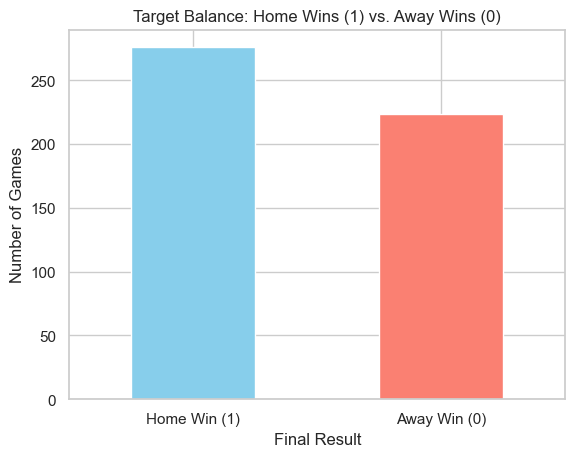

In [23]:
import matplotlib.pyplot as plt

# Group by gameId so the count is by GAMES, not ROWS (one result per game)
game_results = df_clean.groupby('gameId')['HOME_WINS'].first()

game_results.value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Target Balance: Home Wins (1) vs. Away Wins (0)')
plt.xlabel('Final Result')
plt.ylabel('Number of Games')
plt.xticks(ticks=[0, 1], labels=['Home Win (1)', 'Away Win (0)'], rotation=0)
plt.show()

The chart above illustrates the Target Balance of our dataset. With a Home Win rate of ~55%, the sample aligns with historical NBA Home Court Advantage trends while maintaining a balanced distribution (Class 1 vs. Class 0) for robust model training.

## 4.0 Data Export & Serialization
With the data cleaned, downcasted for efficiency, and labeled with the `HOME_WINS` target variable, we now export the dataset to **Apache Parquet** format.

### Why Parquet?
* **Schema Preservation:** Unlike CSV files, Parquet maintains our optimized data types (e.g., `int16`, `category`), preventing the need for re-cleaning in Notebook 02.
* **Storage Efficiency:** The columnar storage and compression significantly reduce the file size on disk.
* **Performance:** Parquet provides faster I/O speeds, which will accelerate the feature engineering phase in the next stage of development.

In [24]:
# Save the final cleaned and labeled dataset
df_clean.to_parquet('../data/nba_cleaned_labeled.parquet', index=False)

# Verification of file creation
import os
file_size = os.path.getsize('../data/nba_cleaned_labeled.parquet') / (1024**2)

print("\033[1mNotebook 01 Success!\033[0m")
print(f"Final File: 'nba_cleaned_labeled.parquet'")
print(f"Final Size: {file_size:.2f} MB")

Notebook 01 Success!
Final File: 'nba_cleaned_labeled.parquet'
Final Size: 3.90 MB
